In [2]:
import duckdb

con = duckdb.connect()
DATA_GLOB = "../../data/interim/transactions_per_year_filtered/*.parquet"

result = con.execute(f"""
    SELECT
        MAX(date),
        MIN(date),
        count(*)
    FROM read_parquet('{DATA_GLOB}')
""").fetchdf()

print(result)

ParserException: Parser Error: syntax error at or near "distinct"

LINE 6:         distinct(artikel_id)
                ^

,filter_status,series,active_days,demand_days,demand_kg,series_share
0,Removed: last-year demand share < 10%,"29,583","18,672,406","764,910","1,067,172.0",45.03%
3,Retained,"23,411","16,888,461","6,438,299","21,636,989.2",35.63%
2,Removed: stale last sale,"12,692","8,817,736","140,650","288,226.6",19.32%
1,Removed: no positive sale,13,"6,720",0,0.0,0.02%


,filter_status,ARTIKEL_ID,MARKT_ID,product_name,active_days,demand_days,last_year_active_days,last_year_demand_days,last_year_demand_active_day_share,last_sale_date,days_since_last_sale,total_demand_kg,max_demand_kg
0,Removed: last-year demand share < 10%,1101206,1100079,Braten Parade,1005,59,356,1,0.28%,2026-01-03 00:00:00,199,124.09,7.72
1,Removed: last-year demand share < 10%,382232,1100084,"Halbe Schweine grob zerlegt, HKL E",1024,7,356,1,0.28%,2026-04-17 00:00:00,95,40.81,18.15
2,Removed: last-year demand share < 10%,840905,1100079,Kalbsbraten,1014,37,356,1,0.28%,2025-12-15 00:00:00,218,38.00,3.17
3,Removed: no positive sale,317149,1250009,Schweinebauch Gefüllt,520,0,304,0,0.00%,NaT,,0.00,0.00
4,Removed: no positive sale,1401490,1250064,SB Grillröllchen,274,0,274,0,0.00%,NaT,,0.00,0.00
5,Removed: no positive sale,388784,1250074,Argentinien Rinderhüfte,217,0,217,0,0.00%,NaT,,0.00,0.00
6,Removed: stale last sale,316623,1150048,Hackfleisch gemischt Schwein und Rind,909,576,304,0,0.00%,2025-06-20 00:00:00,396,"8,956.04",66.69
7,Removed: stale last sale,316629,1150048,Thüringer Mett vom Schwein,909,502,304,0,0.00%,2025-06-20 00:00:00,396,"8,457.88",57.12
8,Removed: stale last sale,1003182,1300006,Schweinenacken schier myTime,909,465,304,0,0.00%,2025-02-15 00:00:00,521,"7,649.49",62.32
9,Retained,316667,1350062,Rinderbraten aus dem Bug,210,21,210,21,10.00%,2026-07-18 00:00:00,3,64.91,7.42


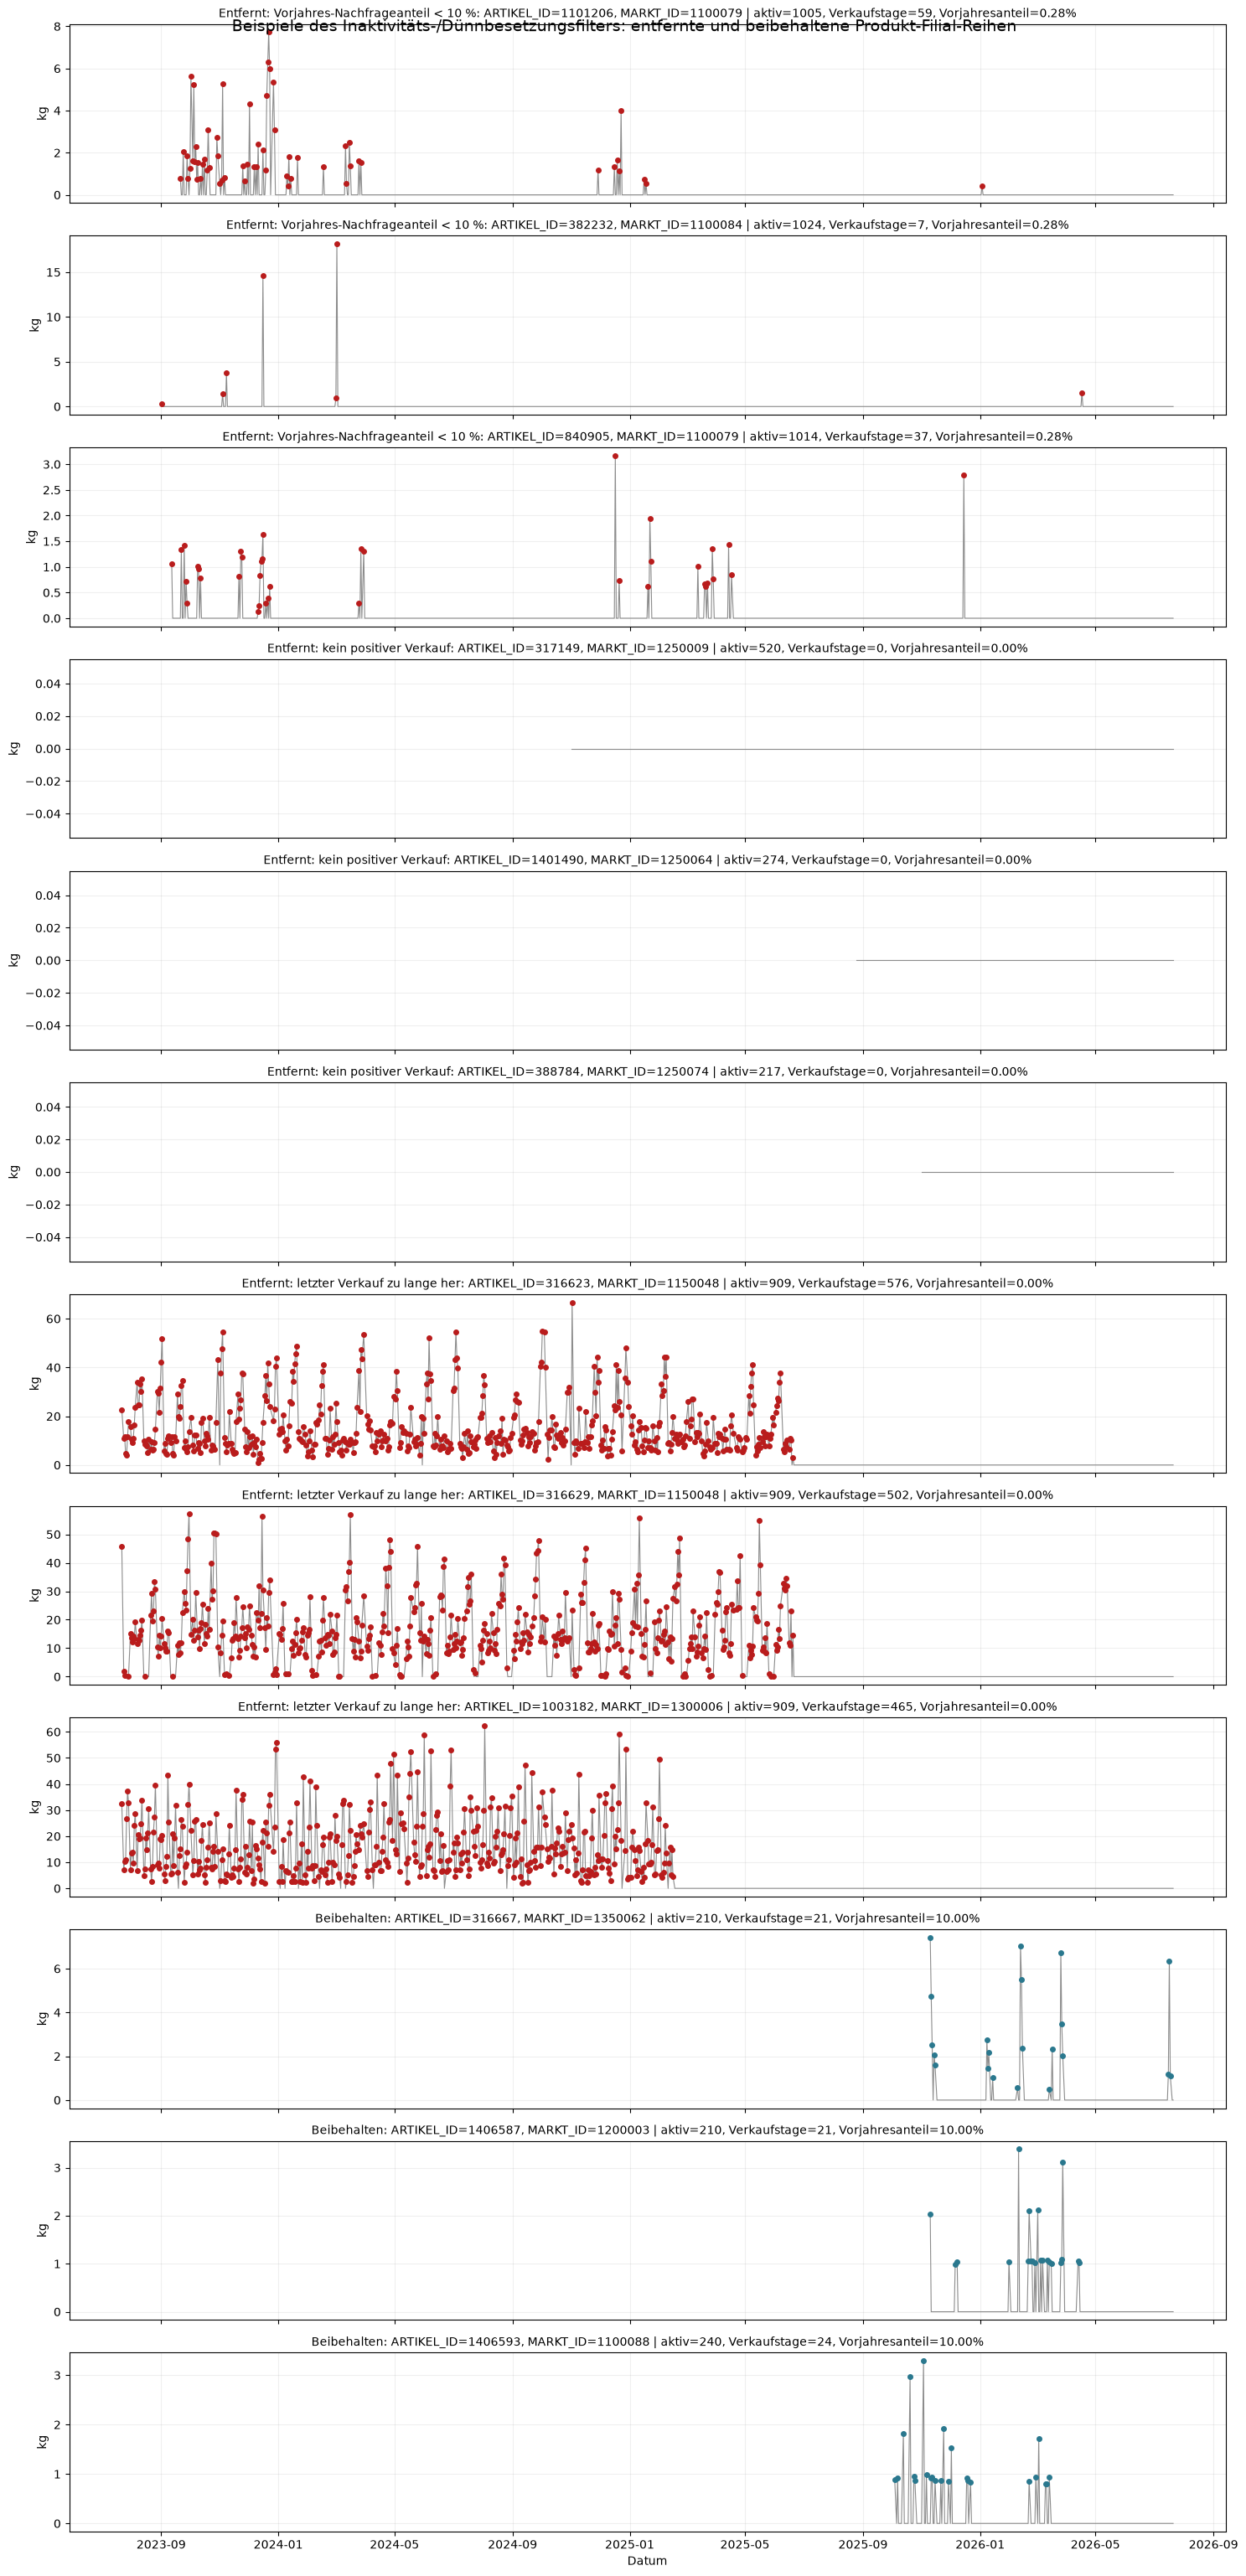

,filter_status,ARTIKEL_ID,MARKT_ID,product_name,active_days,demand_days,last_year_active_days,last_year_demand_days,last_year_demand_active_day_share,distance_to_cutoff,last_sale_date,days_since_last_sale,total_demand_kg,max_demand_kg
0,Removed: last-year demand share < 10%,1399512,1100036,Bockwurst,281,28,281,28,9.964%,0.036%,2026-02-23 00:00:00,148,11.79,1.98
1,Removed: last-year demand share < 10%,1399512,1100003,Bockwurst,281,28,281,28,9.964%,0.036%,2026-06-02 00:00:00,49,8.83,0.74
2,Removed: last-year demand share < 10%,1402822,1300021,SB Schnitzel aus der Oberschale,251,25,251,25,9.960%,0.040%,2026-04-11 00:00:00,101,36.38,4.79
3,Removed: last-year demand share < 10%,1402822,1100015,SB Schnitzel aus der Oberschale,251,25,251,25,9.960%,0.040%,2026-04-11 00:00:00,101,30.97,2.75
4,Retained,316667,1350062,Rinderbraten aus dem Bug,210,21,210,21,10.000%,0.000%,2026-07-18 00:00:00,3,64.91,7.42
5,Retained,1406587,1200003,SB Snirtje Braten vom Schwein,210,21,210,21,10.000%,0.000%,2026-04-14 00:00:00,98,29.46,3.38
6,Retained,1406593,1100088,SB Schweine Rouladen gefüllt,240,24,240,24,10.000%,0.000%,2026-03-14 00:00:00,129,29.26,3.29
7,Retained,1422555,1100009,Gourmetbraten,100,10,100,10,10.000%,0.000%,2026-04-11 00:00:00,101,28.91,7.01


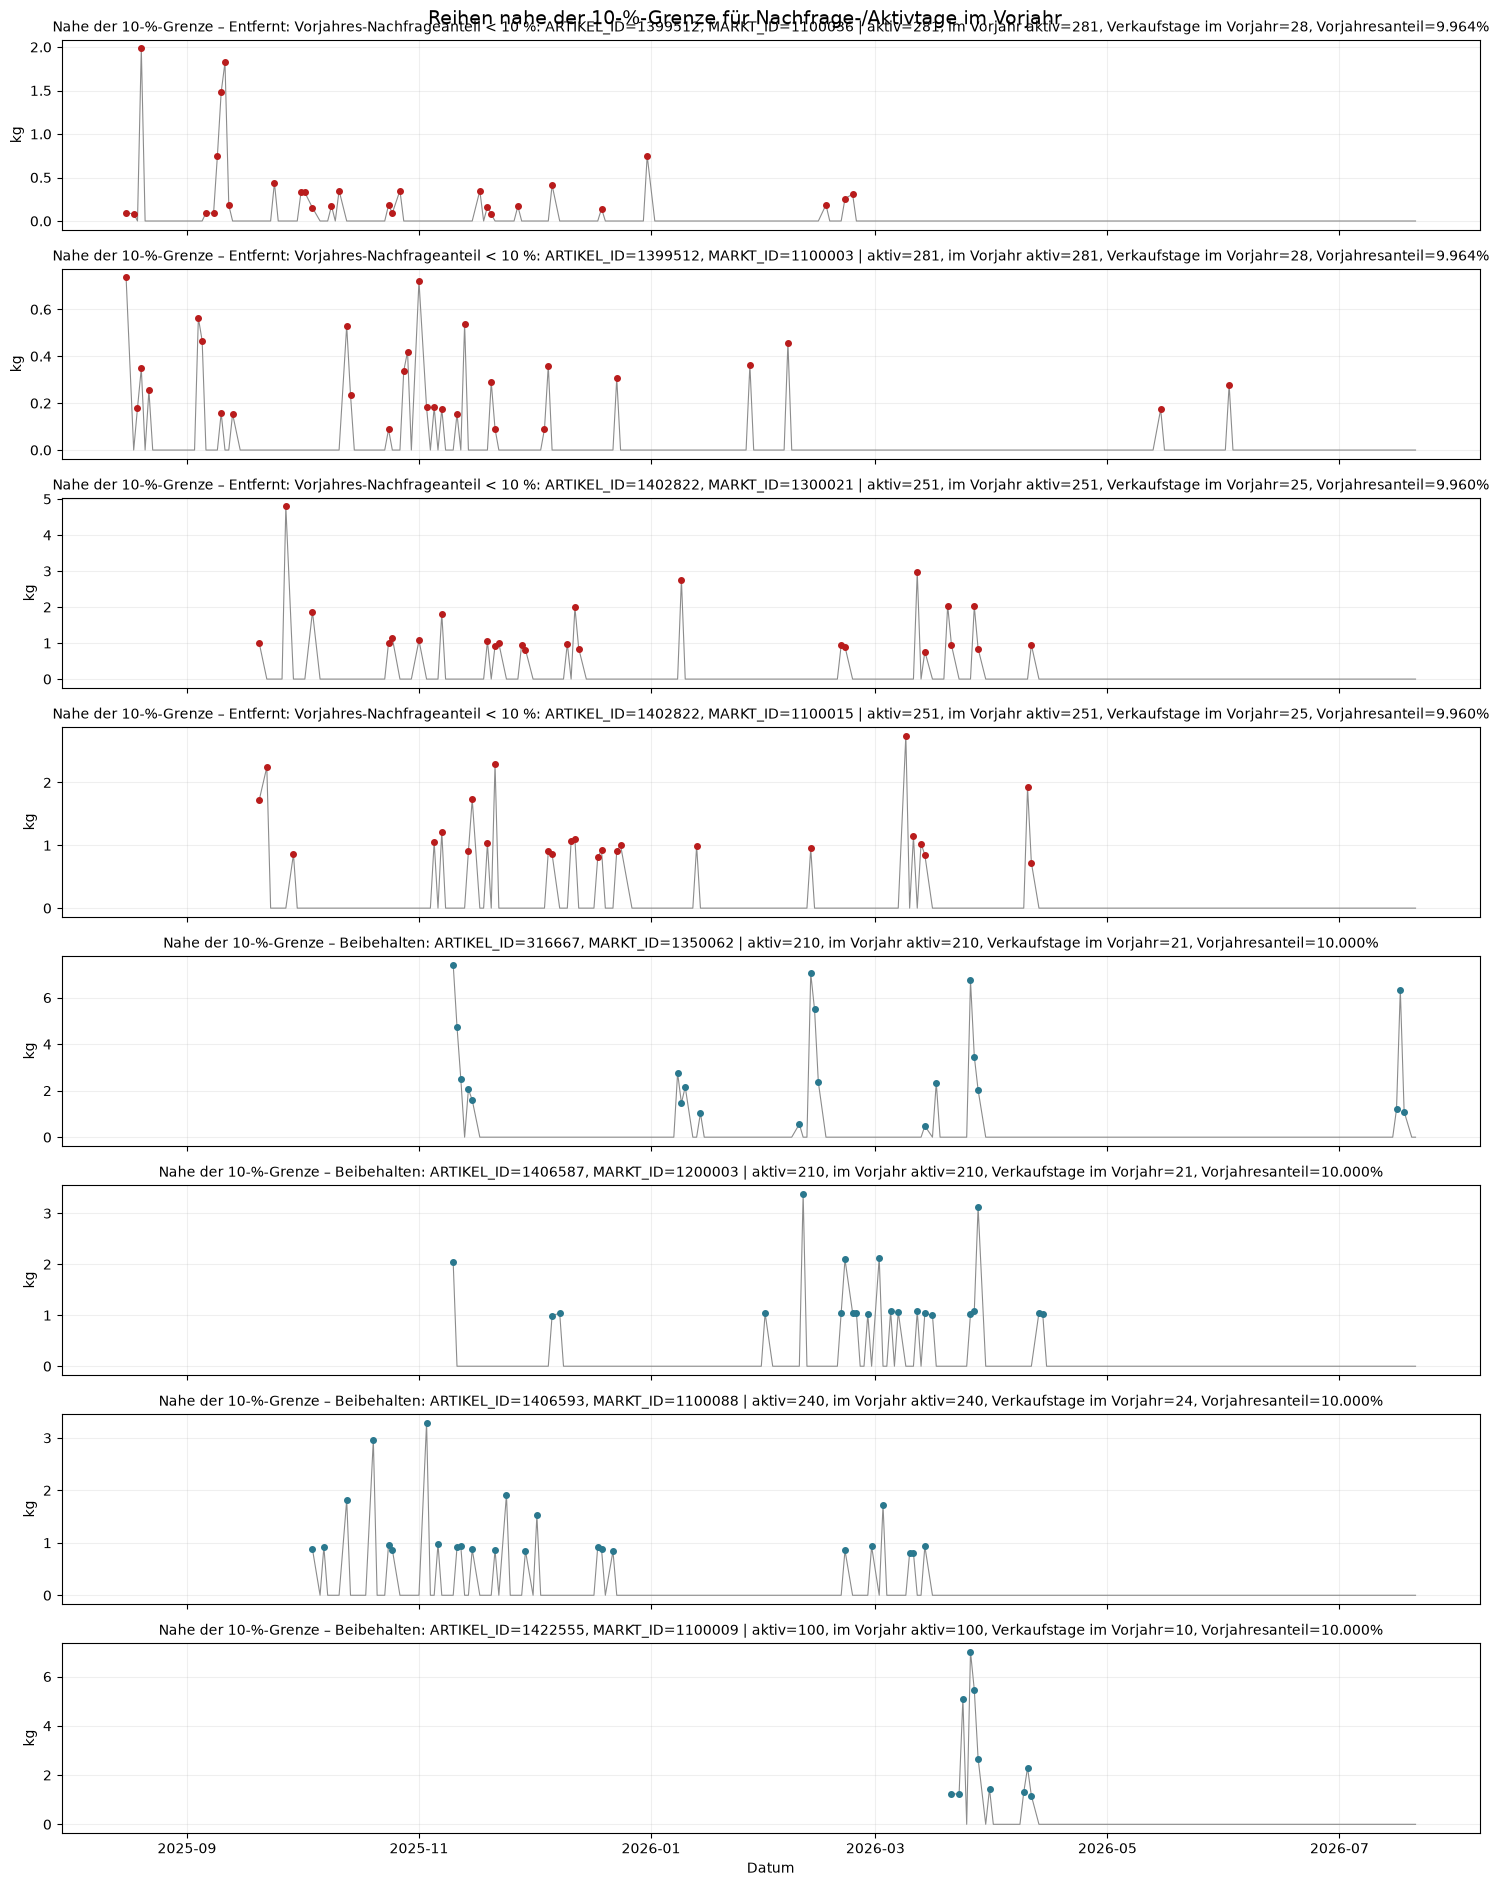

In [1]:
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = next(
    (path.resolve() for path in [Path('../..'), Path('..'), Path('.')] if (path / 'src').exists()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError('Could not find the project root containing src/.')

DATA_GLOB = PROJECT_ROOT / 'data' / 'interim' / 'transactions_dst_daily_no_outliers' / 'transactions_year_*.parquet'
if not list(DATA_GLOB.parent.glob('transactions_year_*.parquet')):
    raise FileNotFoundError(f'No parquet files found at {DATA_GLOB}')

DEMAND_COL = 'ABVERKAUFTE_MENGE_KG'
MAX_DAYS_SINCE_LAST_SALE = 365
MIN_LAST_YEAR_DEMAND_ACTIVE_DAY_SHARE = 0.10
EXAMPLES_PER_CLASS = 3
FILTER_STATUS_LABELS = {
    'Removed: no positive sale': 'Entfernt: kein positiver Verkauf',
    'Removed: stale last sale': 'Entfernt: letzter Verkauf zu lange her',
    'Removed: last-year demand share < 10%': 'Entfernt: Vorjahres-Nachfrageanteil < 10 %',
    'Retained': 'Beibehalten',
}

con = duckdb.connect()
con.execute('PRAGMA threads=8')

con.execute(f"""
CREATE OR REPLACE TEMP VIEW source_rows AS
SELECT
    ARTIKEL_ID,
    MARKT_ID,
    CAST(DATE AS DATE) AS period,
    CAST(COALESCE({DEMAND_COL}, 0) AS DOUBLE) AS demand,
    is_active,
    ARTIKEL_BEZ
FROM read_parquet('{DATA_GLOB}')
""")

series_metrics = con.execute(f"""
WITH dataset_bounds AS (
    SELECT MAX(period) AS max_dataset_date FROM source_rows
),
last_year_source AS (
    SELECT s.*
    FROM source_rows s
    CROSS JOIN dataset_bounds b
    WHERE s.period >= b.max_dataset_date - INTERVAL 365 DAY
),
metrics AS (
    SELECT
        s.ARTIKEL_ID,
        s.MARKT_ID,
        ANY_VALUE(s.ARTIKEL_BEZ) AS product_name,
        COUNT(*) FILTER (WHERE s.is_active)::BIGINT AS active_days,
        COUNT(*) FILTER (WHERE s.is_active AND s.demand > 0)::BIGINT AS demand_days,
        COUNT(*) FILTER (WHERE y.is_active)::BIGINT AS last_year_active_days,
        COUNT(*) FILTER (WHERE y.is_active AND y.demand > 0)::BIGINT AS last_year_demand_days,
        MAX(s.period) FILTER (WHERE s.is_active AND s.demand > 0) AS last_sale_date,
        SUM(s.demand) FILTER (WHERE s.is_active)::DOUBLE AS total_demand_kg,
        MAX(s.demand) FILTER (WHERE s.is_active)::DOUBLE AS max_demand_kg
    FROM source_rows s
    LEFT JOIN last_year_source y
      ON s.ARTIKEL_ID = y.ARTIKEL_ID
     AND s.MARKT_ID = y.MARKT_ID
     AND s.period = y.period
    WHERE s.is_active
    GROUP BY s.ARTIKEL_ID, s.MARKT_ID
)
SELECT
    m.*,
    m.last_year_demand_days::DOUBLE / NULLIF(m.last_year_active_days, 0)
        AS last_year_demand_active_day_share,
    b.max_dataset_date,
    DATE_DIFF('day', m.last_sale_date, b.max_dataset_date) AS days_since_last_sale,
    CASE
        WHEN m.last_sale_date IS NULL THEN 'Removed: no positive sale'
        WHEN DATE_DIFF('day', m.last_sale_date, b.max_dataset_date) > {MAX_DAYS_SINCE_LAST_SALE}
            THEN 'Removed: stale last sale'
        WHEN m.last_year_demand_days::DOUBLE / NULLIF(m.last_year_active_days, 0) < {MIN_LAST_YEAR_DEMAND_ACTIVE_DAY_SHARE}
            THEN 'Removed: last-year demand share < 10%'
        ELSE 'Retained'
    END AS filter_status
FROM metrics m
CROSS JOIN dataset_bounds b
""").fetchdf()

summary = (
    series_metrics.groupby('filter_status', dropna=False)
    .agg(
        series=('ARTIKEL_ID', 'size'),
        active_days=('active_days', 'sum'),
        demand_days=('demand_days', 'sum'),
        demand_kg=('total_demand_kg', 'sum'),
    )
    .reset_index()
    .sort_values('series', ascending=False)
)
summary['series_share'] = summary['series'] / summary['series'].sum()
display(summary.style.format({
    'series': '{:,.0f}',
    'active_days': '{:,.0f}',
    'demand_days': '{:,.0f}',
    'demand_kg': '{:,.1f}',
    'series_share': '{:.2%}',
}))

removed_examples = (
    series_metrics[series_metrics['filter_status'].ne('Retained')]
    .sort_values(['filter_status', 'last_year_demand_active_day_share', 'total_demand_kg'], ascending=[True, True, False])
    .groupby('filter_status', group_keys=False)
    .head(EXAMPLES_PER_CLASS)
)
retained_examples = (
    series_metrics[series_metrics['filter_status'].eq('Retained')]
    .sort_values(['last_year_demand_active_day_share', 'total_demand_kg'], ascending=[True, False])
    .head(EXAMPLES_PER_CLASS)
)
example_keys = pd.concat([removed_examples, retained_examples], ignore_index=True)
display(example_keys[[
    'filter_status', 'ARTIKEL_ID', 'MARKT_ID', 'product_name', 'active_days',
    'demand_days', 'last_year_active_days', 'last_year_demand_days',
    'last_year_demand_active_day_share', 'last_sale_date',
    'days_since_last_sale', 'total_demand_kg', 'max_demand_kg',
]].style.format({
    'last_year_demand_active_day_share': '{:.2%}',
    'total_demand_kg': '{:,.2f}',
    'max_demand_kg': '{:,.2f}',
}))

if example_keys.empty:
    raise RuntimeError('No examples available to plot.')

con.register('example_keys', example_keys[['filter_status', 'ARTIKEL_ID', 'MARKT_ID']])
plot_rows = con.execute("""
SELECT
    e.filter_status,
    s.ARTIKEL_ID,
    s.MARKT_ID,
    s.period,
    s.demand
FROM source_rows s
INNER JOIN example_keys e USING (ARTIKEL_ID, MARKT_ID)
WHERE s.is_active
ORDER BY e.filter_status, s.ARTIKEL_ID, s.MARKT_ID, s.period
""").fetchdf()
plot_rows['period'] = pd.to_datetime(plot_rows['period'])

n = len(example_keys)
fig, axes = plt.subplots(n, 1, figsize=(15, max(2.6 * n, 4)), sharex=True, squeeze=False)
for ax, example in zip(axes[:, 0], example_keys.itertuples(index=False)):
    rows = plot_rows[
        (plot_rows['ARTIKEL_ID'].eq(example.ARTIKEL_ID))
        & (plot_rows['MARKT_ID'].eq(example.MARKT_ID))
    ]
    color = '#b91c1c' if example.filter_status != 'Retained' else '#2a788e'
    ax.plot(rows['period'], rows['demand'], color='0.55', linewidth=0.8)
    positive = rows[rows['demand'] > 0]
    ax.scatter(positive['period'], positive['demand'], color=color, s=16, zorder=3)
    ax.set_ylabel('kg')
    ax.grid(alpha=0.2)
    ax.set_title(
        f"{FILTER_STATUS_LABELS[example.filter_status]}: ARTIKEL_ID={example.ARTIKEL_ID}, MARKT_ID={example.MARKT_ID} | "
        f"aktiv={example.active_days:.0f}, Verkaufstage={example.demand_days:.0f}, "
        f"Vorjahresanteil={example.last_year_demand_active_day_share:.2%}",
        fontsize=10,
    )
axes[-1, 0].set_xlabel('Datum')
fig.suptitle('Beispiele des Inaktivitäts-/Dünnbesetzungsfilters: entfernte und beibehaltene Produkt-Filial-Reihen', fontsize=14)
plt.tight_layout()
plt.show()

BOUNDARY_EXAMPLES_PER_SIDE = 4
low_share_boundary = (
    series_metrics[series_metrics['filter_status'].eq('Removed: last-year demand share < 10%')]
    .assign(distance_to_cutoff=lambda frame: MIN_LAST_YEAR_DEMAND_ACTIVE_DAY_SHARE - frame['last_year_demand_active_day_share'])
    .sort_values(['distance_to_cutoff', 'total_demand_kg'], ascending=[True, False])
    .head(BOUNDARY_EXAMPLES_PER_SIDE)
)
retained_boundary = (
    series_metrics[series_metrics['filter_status'].eq('Retained')]
    .assign(distance_to_cutoff=lambda frame: frame['last_year_demand_active_day_share'] - MIN_LAST_YEAR_DEMAND_ACTIVE_DAY_SHARE)
    .sort_values(['distance_to_cutoff', 'total_demand_kg'], ascending=[True, False])
    .head(BOUNDARY_EXAMPLES_PER_SIDE)
)
boundary_examples = pd.concat([low_share_boundary, retained_boundary], ignore_index=True)
display(boundary_examples[[
    'filter_status', 'ARTIKEL_ID', 'MARKT_ID', 'product_name', 'active_days',
    'demand_days', 'last_year_active_days', 'last_year_demand_days',
    'last_year_demand_active_day_share', 'distance_to_cutoff',
    'last_sale_date', 'days_since_last_sale', 'total_demand_kg', 'max_demand_kg',
]].style.format({
    'last_year_demand_active_day_share': '{:.3%}',
    'distance_to_cutoff': '{:.3%}',
    'total_demand_kg': '{:,.2f}',
    'max_demand_kg': '{:,.2f}',
}))

if boundary_examples.empty:
    raise RuntimeError('No boundary examples available to plot.')

con.register('boundary_examples', boundary_examples[['filter_status', 'ARTIKEL_ID', 'MARKT_ID']])
boundary_plot_rows = con.execute("""
SELECT
    e.filter_status,
    s.ARTIKEL_ID,
    s.MARKT_ID,
    s.period,
    s.demand
FROM source_rows s
INNER JOIN boundary_examples e USING (ARTIKEL_ID, MARKT_ID)
WHERE s.is_active
ORDER BY e.filter_status, s.ARTIKEL_ID, s.MARKT_ID, s.period
""").fetchdf()
boundary_plot_rows['period'] = pd.to_datetime(boundary_plot_rows['period'])

n = len(boundary_examples)
fig, axes = plt.subplots(n, 1, figsize=(15, max(2.4 * n, 4)), sharex=True, squeeze=False)
for ax, example in zip(axes[:, 0], boundary_examples.itertuples(index=False)):
    rows = boundary_plot_rows[
        (boundary_plot_rows['ARTIKEL_ID'].eq(example.ARTIKEL_ID))
        & (boundary_plot_rows['MARKT_ID'].eq(example.MARKT_ID))
    ]
    color = '#b91c1c' if example.filter_status != 'Retained' else '#2a788e'
    ax.plot(rows['period'], rows['demand'], color='0.55', linewidth=0.8)
    positive = rows[rows['demand'] > 0]
    ax.scatter(positive['period'], positive['demand'], color=color, s=16, zorder=3)
    ax.set_ylabel('kg')
    ax.grid(alpha=0.2)
    ax.set_title(
        f"Nahe der 10-%-Grenze – {FILTER_STATUS_LABELS[example.filter_status]}: ARTIKEL_ID={example.ARTIKEL_ID}, "
        f"MARKT_ID={example.MARKT_ID} | aktiv={example.active_days:.0f}, "
        f"im Vorjahr aktiv={example.last_year_active_days:.0f}, "
        f"Verkaufstage im Vorjahr={example.last_year_demand_days:.0f}, "
        f"Vorjahresanteil={example.last_year_demand_active_day_share:.3%}",
        fontsize=10,
    )
axes[-1, 0].set_xlabel('Datum')
fig.suptitle('Reihen nahe der 10-%-Grenze für Nachfrage-/Aktivtage im Vorjahr', fontsize=14)
plt.tight_layout()
plt.show()


In [2]:
DATA = PROJECT_ROOT / 'data' / 'processed' / 'transactions' / 'transactions_year_*.parquet'
con.execute(f"""
select artikel_id, markt_id, min(date), first(is_fcm) from read_parquet('{DATA}')
group by artikel_id, markt_id
having min(date(DATE)) > '2026-03-02'
""").fetchdf()

,ARTIKEL_ID,MARKT_ID,min(date),"""first""(is_fcm)"
0,594066,1300013,2026-03-17,False
1,317200,1350073,2026-04-11,False
2,594066,1100008,2026-03-19,False
3,594066,1250006,2026-03-17,False
4,594066,1250064,2026-04-14,False
...,...,...,...,...
307,1425927,1250048,2026-04-07,True
308,1023161,1100059,2026-06-10,False
309,316654,1100092,2026-06-18,False
310,594066,1200036,2026-03-17,False
